In [1]:
word =  open('/content/names.txt', 'r').read().splitlines()
len(word)

32033

**bigram**

In [ ]:
b = {}
for w in word:
  ch = ['<S>']+ list(w) + ['<E>']
  for ch1, ch2 in zip(w, w[1:]):
    bigram = (ch1,ch2)
    b[bigram]  = b.get(bigram,0) + 1


In [ ]:
# sorted(b.items(), key= lambda kv : -kv[1])
sorted(b.items(), key= lambda kv : kv[1])

[(('q', 'r'), 1),
 (('d', 'z'), 1),
 (('p', 'j'), 1),
 (('q', 'l'), 1),
 (('p', 'f'), 1),
 (('q', 'e'), 1),
 (('b', 'c'), 1),
 (('c', 'd'), 1),
 (('m', 'f'), 1),
 (('p', 'n'), 1),
 (('w', 'b'), 1),
 (('p', 'c'), 1),
 (('h', 'p'), 1),
 (('f', 'h'), 1),
 (('b', 'j'), 1),
 (('f', 'g'), 1),
 (('z', 'g'), 1),
 (('c', 'p'), 1),
 (('p', 'k'), 1),
 (('p', 'm'), 1),
 (('x', 'n'), 1),
 (('s', 'q'), 1),
 (('k', 'f'), 1),
 (('m', 'k'), 1),
 (('x', 'h'), 1),
 (('g', 'f'), 1),
 (('v', 'b'), 1),
 (('j', 'p'), 1),
 (('g', 'z'), 1),
 (('v', 'd'), 1),
 (('d', 'b'), 1),
 (('v', 'h'), 1),
 (('h', 'h'), 1),
 (('g', 'v'), 1),
 (('d', 'q'), 1),
 (('x', 'b'), 1),
 (('w', 'z'), 1),
 (('h', 'q'), 1),
 (('j', 'b'), 1),
 (('x', 'm'), 1),
 (('w', 'g'), 1),
 (('t', 'b'), 1),
 (('z', 'x'), 1),
 (('p', 'b'), 2),
 (('t', 'g'), 2),
 (('q', 's'), 2),
 (('t', 'x'), 2),
 (('f', 'k'), 2),
 (('b', 't'), 2),
 (('j', 'n'), 2),
 (('k', 'c'), 2),
 (('z', 'k'), 2),
 (('s', 'j'), 2),
 (('s', 'f'), 2),
 (('z', 'j'), 2),
 (('n', 'q

In [2]:
import torch

In [3]:
# we are taking size as 27 = 26 (aplhabets)+ 1(., .)
N= torch.zeros((27,27),dtype=torch.int32)

In [15]:
chars = sorted(list(set(''.join(word))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.']= 0
itos = {i:s for s,i in stoi.items()}

In [24]:
b = {}
for w in word:
  ch = ['.']+ list(w) + ['.']
  for ch1, ch2 in zip(ch, ch[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1,ix2] += 1

In [25]:
N[0]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

**Print torch heatmap**

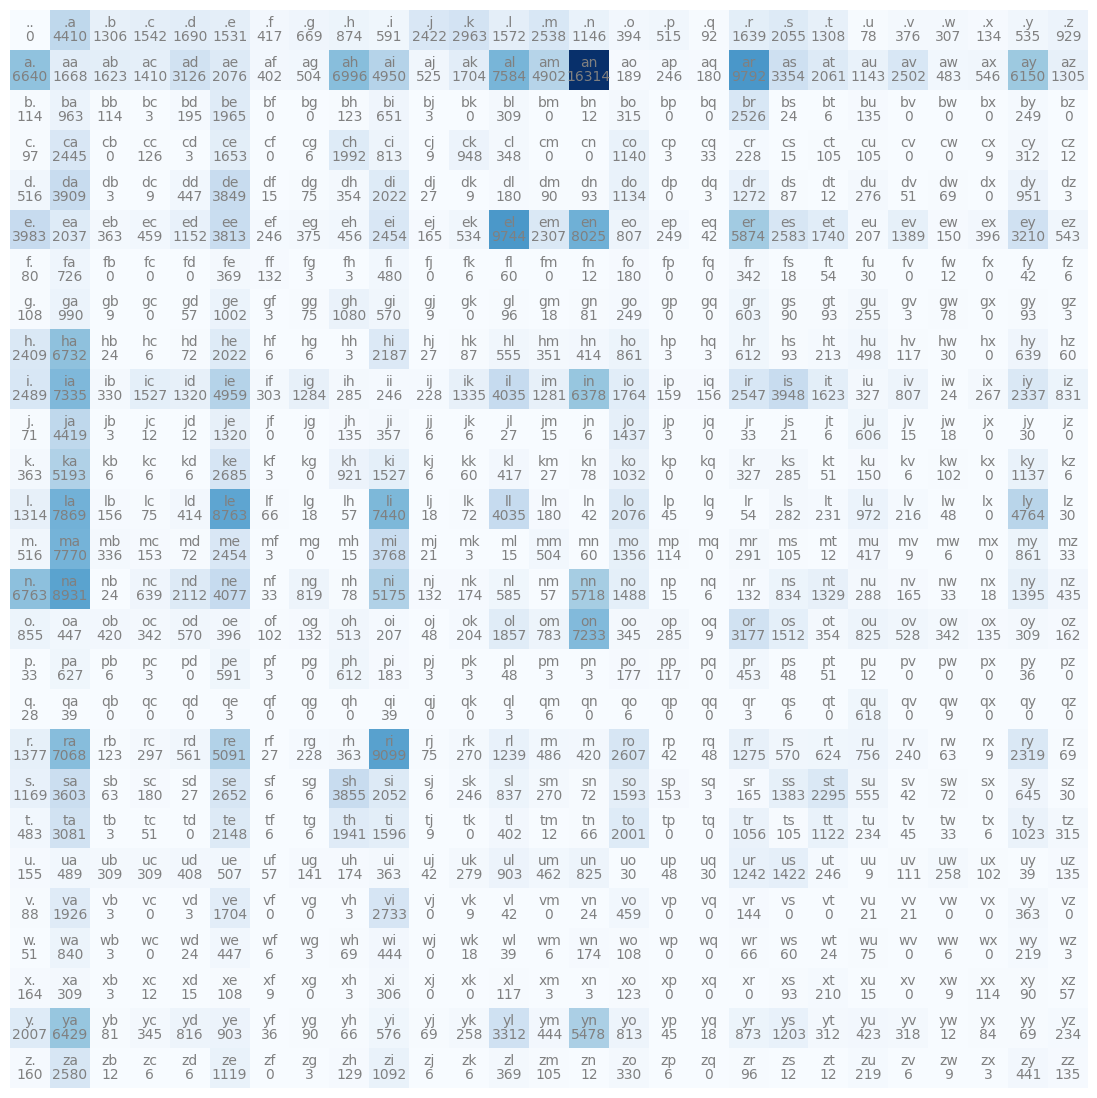

In [26]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(14,14))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [31]:
P = N.float()
P = P / P.sum(1, keepdim =True)
P[0].sum()

tensor(1.)

In [34]:
g = torch.Generator().manual_seed(2147483647)
for i in range(20):
  ix = 0
  out = ''
  while True:
    # this is ineffiecient
    # p = N[ix].float()
    # p = p/ p.sum()
    p = P[ix]
    ix = torch.multinomial(p, num_samples = 1, replacement= True, generator= g).item()
    out += itos[ix]
    if ix == 0:
      break
  print(out)



cexze.
momasurailezitynnelllimittainellayn.
kanar.
staiyaubrtthrigotai.
moliellavo.
ke.
tedaren.
emimmsadey.
nkaviynylytlspihinivenvorhlasu.
dsordeleenleryawaisana.
ra.
dineeezem.
deru.
firit.
gaikajahahbevare.
kiysthelenaririenah.
keenan.
alesilmahavazeeromysoshlaitenimieegariseriyennn.
illeleldolesieenisammigamanemin.
asharin.


In [35]:
# GOAL: maximize likelihood of the data w.r.t. model parameters (statistical modeling)
# equivalent to maximizing the log likelihood (because log is monotonic)
# equivalent to minimizing the negative log likelihood
# equivalent to minimizing the average negative log likelihood

# log(a*b*c) = log(a) + log(b) + log(c)

In [37]:
log_likelihood = 0.0
n = 0

for w in word:
#for w in ["abhinav"]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    logprob = torch.log(prob)
    log_likelihood += logprob
    n += 1
    #print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-571912.8750)
nll=tensor(571912.8750)
2.506784677505493


**Neural Net bigram**

In [39]:
xs , ys = [], []
for w in word:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

In [41]:
xs

tensor([ 0,  5, 13,  ..., 25, 26, 24])

In [46]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes= len(stoi.keys()))
xenc

tensor([[1, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 1, 0],
        [0, 0, 0,  ..., 0, 0, 1],
        [0, 0, 0,  ..., 1, 0, 0]])